In [2]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# =========================
# Data Handling
# =========================
import pandas as pd
import numpy as np

# =========================
# Visualization
# =========================
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Data Preprocessing
# =========================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# =========================
# Machine Learning Models
# =========================
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# XGBoost
from xgboost import XGBRegressor

# =========================
# Model Evaluation
# =========================
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# =========================
# Hyperparameter Tuning
# =========================
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# =========================
# Model Saving
# =========================
import pickle
import joblib

# =========================
# Ignore Warnings
# =========================
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('../Data/laptop_price.csv', encoding='latin1')
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [5]:
df.tail()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
1298,1316,Lenovo,Yoga 500-14ISK,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,638.0
1299,1317,Lenovo,Yoga 900-13ISK,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,1499.0
1300,1318,Lenovo,IdeaPad 100S-14IBR,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,229.0
1301,1319,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,764.0
1302,1320,Asus,X553SA-XX031T (N3050/4GB/500GB/W10),Notebook,15.6,1366x768,Intel Celeron Dual Core N3050 1.6GHz,4GB,500GB HDD,Intel HD Graphics,Windows 10,2.2kg,369.0


In [6]:
df.shape

(1303, 13)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   str    
 2   Product           1303 non-null   str    
 3   TypeName          1303 non-null   str    
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   str    
 6   Cpu               1303 non-null   str    
 7   Ram               1303 non-null   str    
 8   Memory            1303 non-null   str    
 9   Gpu               1303 non-null   str    
 10  OpSys             1303 non-null   str    
 11  Weight            1303 non-null   str    
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), str(10)
memory usage: 291.0 KB


In [8]:
exchange_rate = 109

df['Price_inr'] = df['Price_euros'] * exchange_rate

In [9]:
df['Price_inr'].head()

0    146026.21
1     97984.46
2     62675.00
3    276582.05
4    196592.40
Name: Price_inr, dtype: float64

In [10]:
df.drop(columns=['Price_euros'], inplace=True)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   str    
 2   Product           1303 non-null   str    
 3   TypeName          1303 non-null   str    
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   str    
 6   Cpu               1303 non-null   str    
 7   Ram               1303 non-null   str    
 8   Memory            1303 non-null   str    
 9   Gpu               1303 non-null   str    
 10  OpSys             1303 non-null   str    
 11  Weight            1303 non-null   str    
 12  Price_inr         1303 non-null   float64
dtypes: float64(2), int64(1), str(10)
memory usage: 291.0 KB


In [12]:
df.isnull().sum()

laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_inr           0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.columns

Index(['laptop_ID', 'Company', 'Product', 'TypeName', 'Inches',
       'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight',
       'Price_inr'],
      dtype='str')

In [15]:
df.drop(columns=['laptop_ID','Product'], inplace=True)

In [16]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_inr
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,146026.21
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,97984.46
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,62675.00
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,276582.05
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,196592.40


In [17]:
df['Company'].value_counts()

Company
Dell         297
Lenovo       297
HP           274
Asus         158
Acer         103
MSI           54
Toshiba       48
Apple         21
Samsung        9
Razer          7
Mediacom       7
Microsoft      6
Xiaomi         4
Vero           4
Chuwi          3
Google         3
Fujitsu        3
LG             3
Huawei         2
Name: count, dtype: int64

In [18]:
df['TypeName'].value_counts()

TypeName
Notebook              727
Gaming                205
Ultrabook             196
2 in 1 Convertible    121
Workstation            29
Netbook                25
Name: count, dtype: int64

In [19]:
df['Ram'].value_counts()

Ram
8GB     619
4GB     375
16GB    200
6GB      41
12GB     25
2GB      22
32GB     17
24GB      3
64GB      1
Name: count, dtype: int64

In [20]:
df['OpSys'].value_counts()

OpSys
Windows 10      1072
No OS             66
Linux             62
Windows 7         45
Chrome OS         27
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64

In [21]:
# Convert RAM from '8GB' -> 8
df['Ram'] = df['Ram'].str.replace('GB', '').astype(float)

# Convert Weight from '1.37kg' -> 1.37
df['Weight'] = df['Weight'].str.replace('kg', '').astype(float)

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   str    
 1   TypeName          1303 non-null   str    
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   str    
 4   Cpu               1303 non-null   str    
 5   Ram               1303 non-null   float64
 6   Memory            1303 non-null   str    
 7   Gpu               1303 non-null   str    
 8   OpSys             1303 non-null   str    
 9   Weight            1303 non-null   float64
 10  Price_inr         1303 non-null   float64
dtypes: float64(4), str(7)
memory usage: 239.8 KB


In [23]:
df.describe()

,Inches,Ram,Weight,Price_inr
count,1303.000000,1303.000000,1303.000000,1303.000000
mean,15.017191,8.382195,2.038734,122481.882080
std,1.426304,5.084665,0.665475,76191.985636
min,10.100000,2.000000,0.690000,18966.000000
25%,14.000000,4.000000,1.500000,65291.000000
50%,15.600000,8.000000,2.040000,106493.000000
75%,15.600000,8.000000,2.300000,162178.920000
max,18.400000,64.000000,4.700000,664791.000000


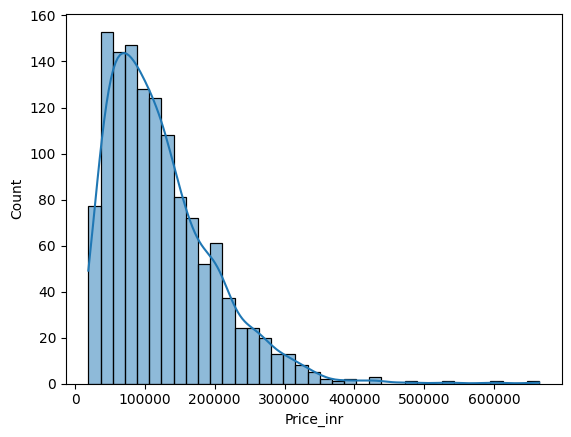

In [24]:
# Target variable distribution
sns.histplot(df['Price_inr'], kde=True)
plt.show()

In [25]:
# Average price by company
df.groupby('Company')['Price_inr'].mean().sort_values(ascending=False)

Company
Razer        364729.571429
LG           228791.000000
MSI          188450.988148
Google       182865.666667
Microsoft    175741.608333
Apple        170497.644286
Huawei       155216.000000
Samsung      154065.444444
Toshiba      138191.562500
Dell         129281.519899
Xiaomi       123547.412500
Asus         120354.461013
Lenovo       118415.904444
HP           116387.459088
Fujitsu       79461.000000
Acer          68318.564951
Chuwi         34258.336667
Mediacom      32155.000000
Vero          23699.325000
Name: Price_inr, dtype: float64

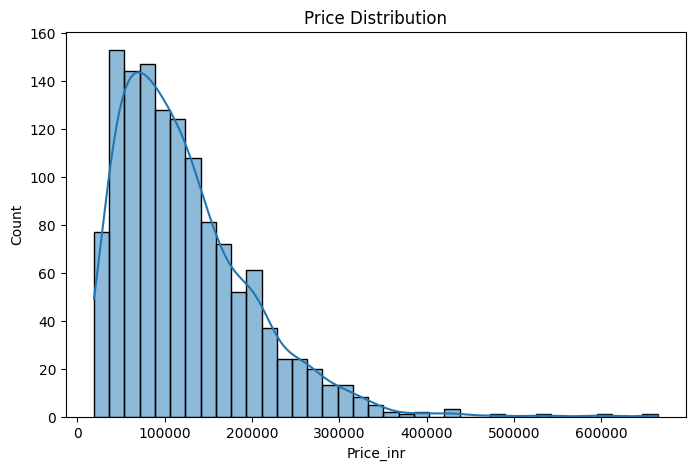

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price_inr'], kde=True)
plt.title('Price Distribution')
plt.show()

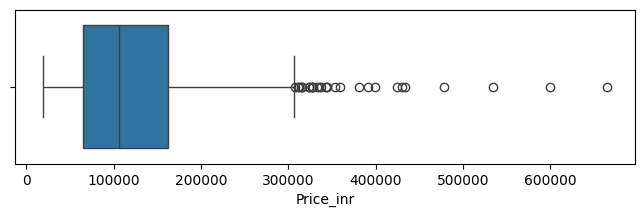

In [27]:
plt.figure(figsize=(8,2))
sns.boxplot(x=df['Price_inr'])
plt.show()

In [28]:
df['Company'].value_counts()

Company
Dell         297
Lenovo       297
HP           274
Asus         158
Acer         103
MSI           54
Toshiba       48
Apple         21
Samsung        9
Razer          7
Mediacom       7
Microsoft      6
Xiaomi         4
Vero           4
Chuwi          3
Google         3
Fujitsu        3
LG             3
Huawei         2
Name: count, dtype: int64

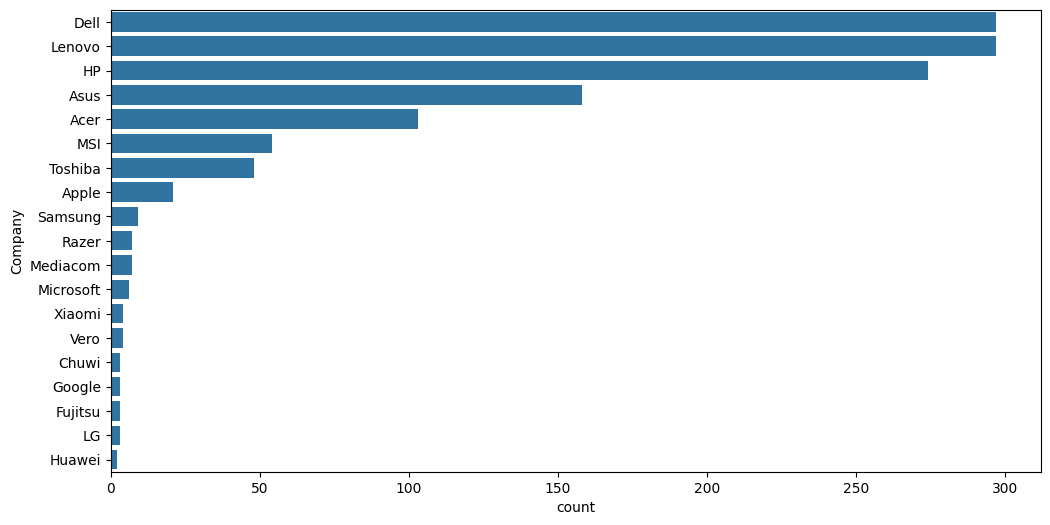

In [29]:
plt.figure(figsize=(12,6))
sns.countplot(y='Company', data=df,
              order=df['Company'].value_counts().index)
plt.show()

In [30]:
df['TypeName'].value_counts()

TypeName
Notebook              727
Gaming                205
Ultrabook             196
2 in 1 Convertible    121
Workstation            29
Netbook                25
Name: count, dtype: int64

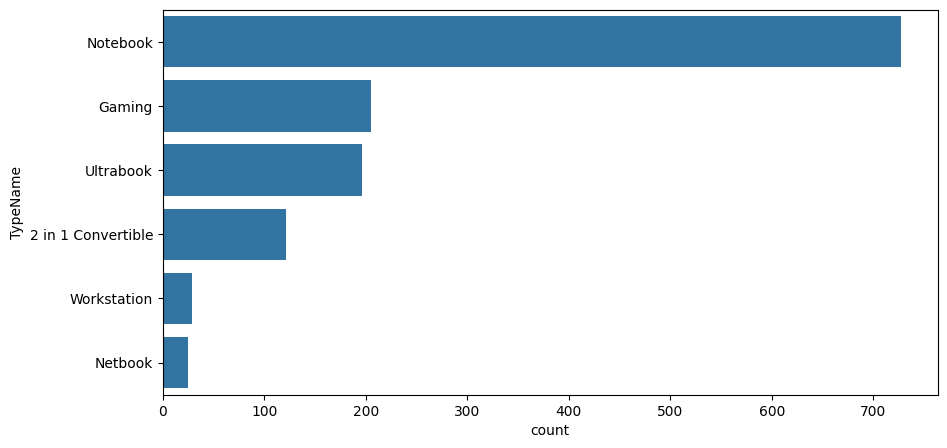

In [31]:
plt.figure(figsize=(10,5))
sns.countplot(y='TypeName', data=df,
              order=df['TypeName'].value_counts().index)
plt.show()

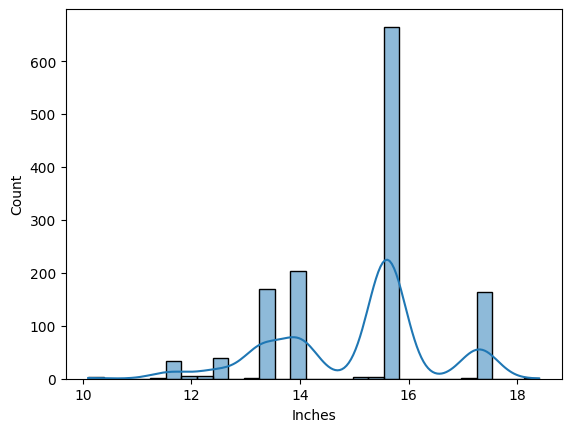

In [32]:
sns.histplot(df['Inches'], kde=True)
plt.show()

In [33]:
df['Ram'].value_counts().sort_index()

Ram
2.0      22
4.0     375
6.0      41
8.0     619
12.0     25
16.0    200
24.0      3
32.0     17
64.0      1
Name: count, dtype: int64

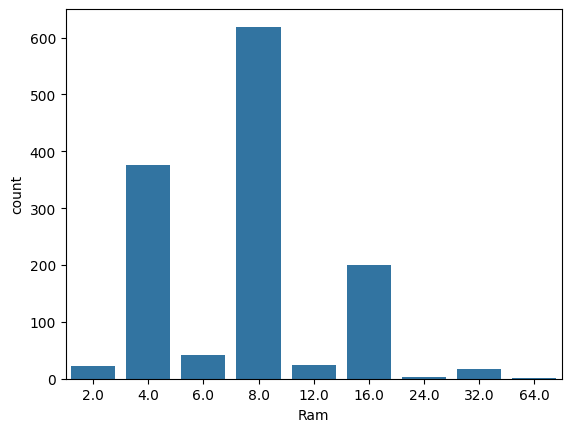

In [34]:
sns.countplot(x='Ram', data=df)
plt.show()

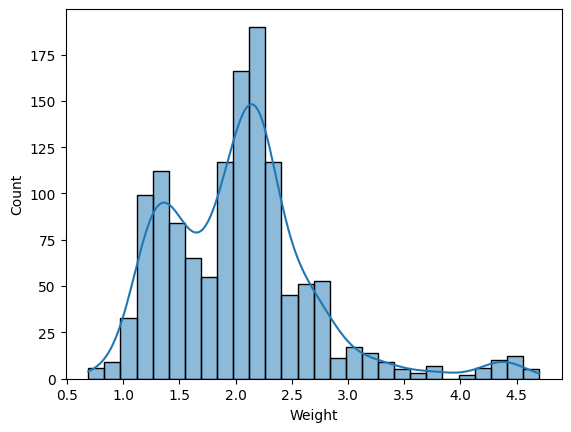

In [35]:
sns.histplot(df['Weight'], kde=True)
plt.show()

In [36]:
df['ScreenResolution'].value_counts()

ScreenResolution
Full HD 1920x1080                                507
1366x768                                         281
IPS Panel Full HD 1920x1080                      230
IPS Panel Full HD / Touchscreen 1920x1080         53
Full HD / Touchscreen 1920x1080                   47
1600x900                                          23
Touchscreen 1366x768                              16
Quad HD+ / Touchscreen 3200x1800                  15
IPS Panel 4K Ultra HD 3840x2160                   12
IPS Panel 4K Ultra HD / Touchscreen 3840x2160     11
4K Ultra HD / Touchscreen 3840x2160               10
IPS Panel 1366x768                                 7
Touchscreen 2560x1440                              7
4K Ultra HD 3840x2160                              7
IPS Panel Retina Display 2560x1600                 6
IPS Panel Retina Display 2304x1440                 6
Touchscreen 2256x1504                              6
IPS Panel Quad HD+ / Touchscreen 3200x1800         6
IPS Panel Touchscreen 2560x14

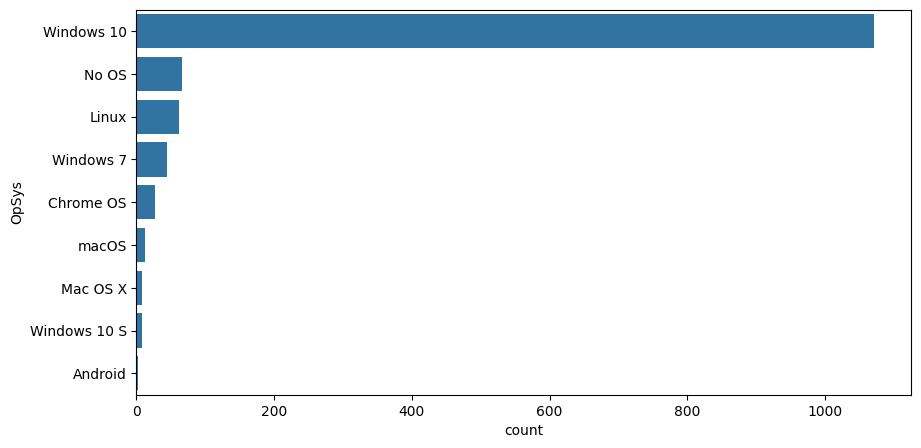

In [37]:
plt.figure(figsize=(10,5))
sns.countplot(y='OpSys', data=df,
              order=df['OpSys'].value_counts().index)
plt.show()

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   str    
 1   TypeName          1303 non-null   str    
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   str    
 4   Cpu               1303 non-null   str    
 5   Ram               1303 non-null   float64
 6   Memory            1303 non-null   str    
 7   Gpu               1303 non-null   str    
 8   OpSys             1303 non-null   str    
 9   Weight            1303 non-null   float64
 10  Price_inr         1303 non-null   float64
dtypes: float64(4), str(7)
memory usage: 239.8 KB


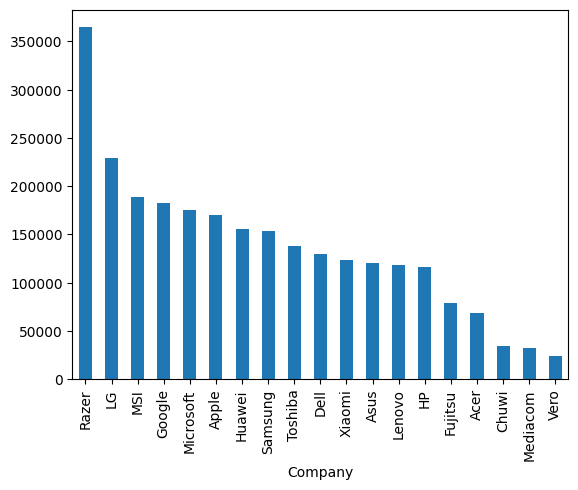

In [39]:
df.groupby('Company')['Price_inr'].mean().sort_values(ascending=False).plot.bar()
plt.show()

In [40]:
df.groupby('OpSys')['Price_inr'].mean().sort_values(ascending=False)

OpSys
macOS           190709.753846
Windows 7       183844.995333
Windows 10 S    140226.320000
Mac OS X        137652.966250
Windows 10      127327.203060
Linux            67260.506935
No OS            64089.093333
Chrome OS        60340.785185
Android          47306.000000
Name: Price_inr, dtype: float64

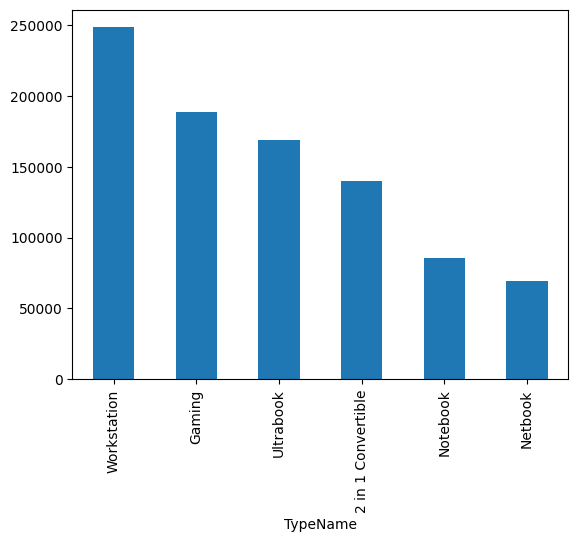

In [41]:
df.groupby('TypeName')['Price_inr'].mean().sort_values(ascending=False).plot.bar()
plt.show()

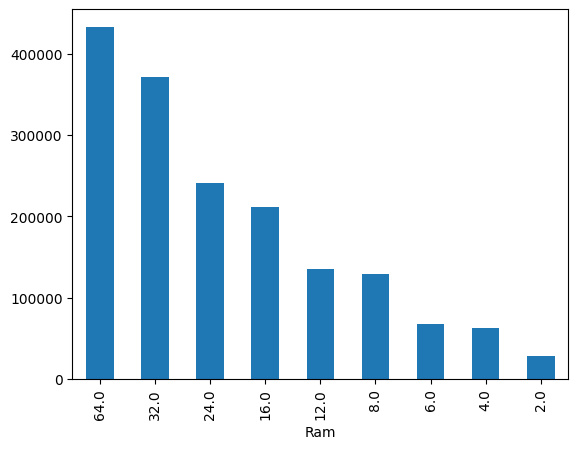

In [42]:
df.groupby('Ram')['Price_inr'].mean().sort_values(ascending=False).plot.bar()
plt.show()

In [43]:
df['Touchscreen'] = df['ScreenResolution'].apply(
    lambda x: 1 if 'Touchscreen' in x else 0
)

In [44]:
df['Touchscreen'].value_counts()

Touchscreen
0    1111
1     192
Name: count, dtype: int64

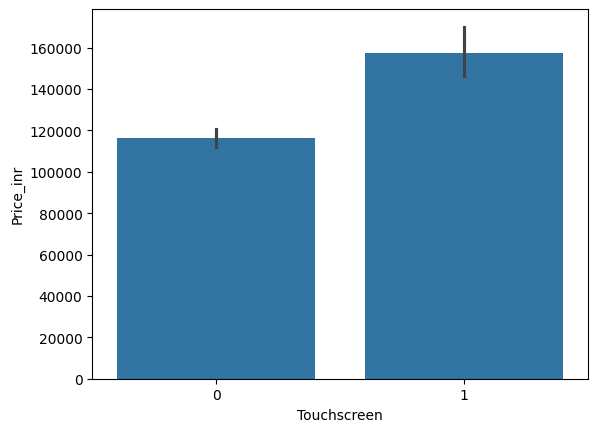

In [45]:
sns.barplot(x='Touchscreen', y='Price_inr', data=df)
plt.show()

In [46]:
df['IPS'] = df['ScreenResolution'].apply(
    lambda x: 1 if 'IPS' in x else 0
)

In [47]:
df['IPS'].value_counts()

IPS
0    938
1    365
Name: count, dtype: int64

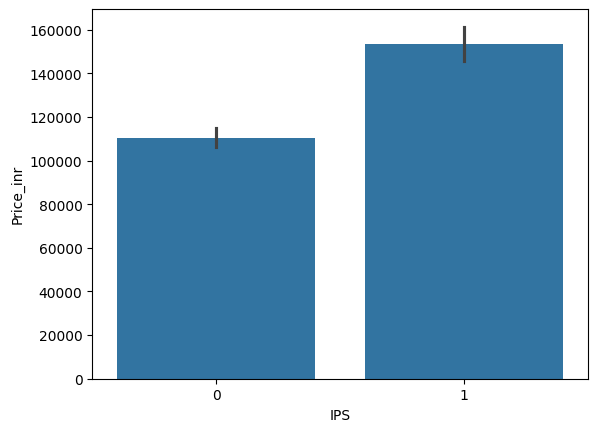

In [48]:
sns.barplot(x='IPS', y='Price_inr', data=df)
plt.show()

In [49]:
# Extract resolution part (e.g., 1920x1080)
df['Resolution'] = df['ScreenResolution'].str.extract(r'(\d+x\d+)')

# Split into X and Y resolution
df['X_res'] = df['Resolution'].str.split('x').str[0].astype(int)
df['Y_res'] = df['Resolution'].str.split('x').str[1].astype(int)

# Optional: remove temporary column
df.drop(columns=['Resolution'], inplace=True)

<Axes: ylabel='X_res'>

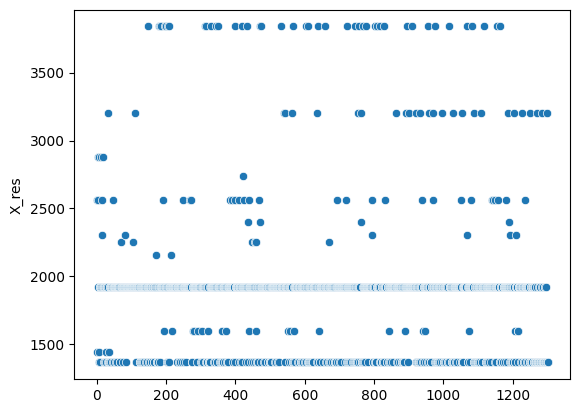

In [50]:
sns.scatterplot(df['X_res'])

In [51]:
df['X_res'].value_counts()

X_res
1920    846
1366    308
3840     43
2560     29
3200     27
1600     23
2304      6
2256      6
1440      4
2880      4
2400      4
2160      2
2736      1
Name: count, dtype: int64

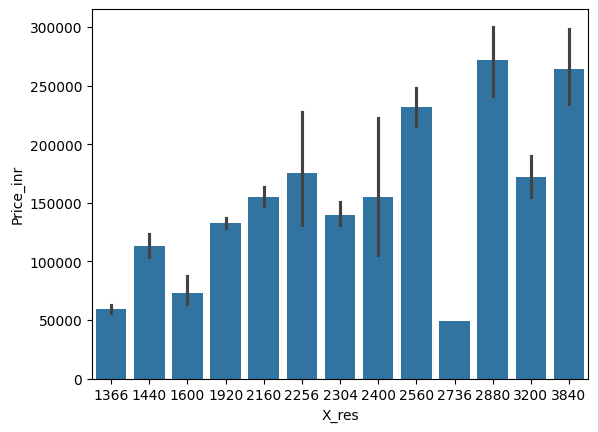

In [52]:
sns.barplot(x='X_res', y='Price_inr', data=df)
plt.show()
#

In [53]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_inr,Touchscreen,IPS,X_res,Y_res
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8.0,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,146026.21,0,1,2560,1600
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8.0,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,97984.46,0,0,1440,900
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8.0,256GB SSD,Intel HD Graphics 620,No OS,1.86,62675.00,0,0,1920,1080
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16.0,512GB SSD,AMD Radeon Pro 455,macOS,1.83,276582.05,0,1,2880,1800
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8.0,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,196592.40,0,1,2560,1600


In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   str    
 1   TypeName          1303 non-null   str    
 2   Inches            1303 non-null   float64
 3   ScreenResolution  1303 non-null   str    
 4   Cpu               1303 non-null   str    
 5   Ram               1303 non-null   float64
 6   Memory            1303 non-null   str    
 7   Gpu               1303 non-null   str    
 8   OpSys             1303 non-null   str    
 9   Weight            1303 non-null   float64
 10  Price_inr         1303 non-null   float64
 11  Touchscreen       1303 non-null   int64  
 12  IPS               1303 non-null   int64  
 13  X_res             1303 non-null   int64  
 14  Y_res             1303 non-null   int64  
dtypes: float64(4), int64(4), str(7)
memory usage: 280.6 KB


In [55]:
df.corr(numeric_only=True)['Price_inr']

Inches         0.068197
Ram            0.743007
Weight         0.210370
Price_inr      1.000000
Touchscreen    0.191226
IPS            0.252208
X_res          0.556529
Y_res          0.552809
Name: Price_inr, dtype: float64

In [56]:
import numpy as np

df['PPI'] = np.sqrt(df['X_res']**2 + df['Y_res']**2) / df['Inches']

In [57]:
df['PPI']

0       226.983005
1       127.677940
2       141.211998
3       220.534624
4       226.983005
           ...    
1298    157.350512
1299    276.053530
1300    111.935204
1301    100.454670
1302    100.454670
Name: PPI, Length: 1303, dtype: float64

In [58]:
df.drop(columns=['X_res', 'Y_res', 'Inches'], inplace=True)

In [59]:
df.corr(numeric_only=True)['Price_inr'].sort_values(ascending=False)

Price_inr      1.000000
Ram            0.743007
PPI            0.473487
IPS            0.252208
Weight         0.210370
Touchscreen    0.191226
Name: Price_inr, dtype: float64

In [60]:
df.drop(columns=['ScreenResolution'], inplace=True)

In [61]:
df.head()

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_inr,Touchscreen,IPS,PPI
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8.0,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,146026.21,0,1,226.983005
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8.0,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,97984.46,0,0,127.677940
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8.0,256GB SSD,Intel HD Graphics 620,No OS,1.86,62675.00,0,0,141.211998
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16.0,512GB SSD,AMD Radeon Pro 455,macOS,1.83,276582.05,0,1,220.534624
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8.0,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,196592.40,0,1,226.983005


In [62]:
df['Cpu_name'] = df['Cpu'].apply(lambda x: " ".join(x.split()[:3]))

In [63]:
def fetch_processor(text):
    if text in ['Intel Core i3', 'Intel Core i5', 'Intel Core i7']:
        return text
    elif text.startswith('Intel'):
        return 'Other Intel Processor'
    else:
        return 'AMD Processor'

In [64]:
df['Cpu_brand'] = df['Cpu_name'].apply(fetch_processor)

In [65]:
df.drop(columns=['Cpu_name'], inplace=True)

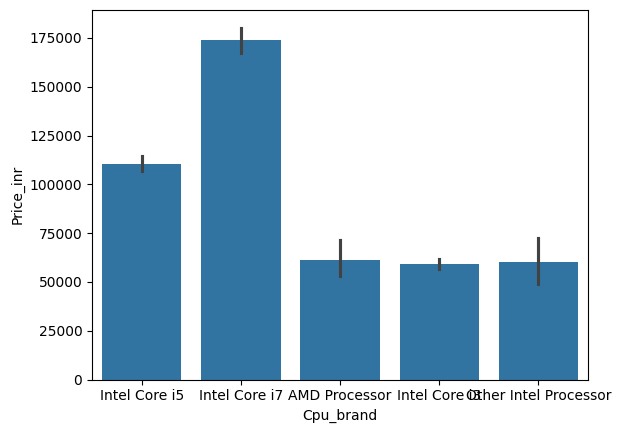

In [66]:
sns.barplot(x='Cpu_brand', y='Price_inr', data=df)
plt.show()

In [67]:
df.drop(columns=['Cpu'], inplace=True)

In [68]:
df.head()

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price_inr,Touchscreen,IPS,PPI,Cpu_brand
0,Apple,Ultrabook,8.0,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,146026.21,0,1,226.983005,Intel Core i5
1,Apple,Ultrabook,8.0,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,97984.46,0,0,127.677940,Intel Core i5
2,HP,Notebook,8.0,256GB SSD,Intel HD Graphics 620,No OS,1.86,62675.00,0,0,141.211998,Intel Core i5
3,Apple,Ultrabook,16.0,512GB SSD,AMD Radeon Pro 455,macOS,1.83,276582.05,0,1,220.534624,Intel Core i7
4,Apple,Ultrabook,8.0,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,196592.40,0,1,226.983005,Intel Core i5


In [69]:
df['Gpu'].value_counts()

Gpu
Intel HD Graphics 620      281
Intel HD Graphics 520      185
Intel UHD Graphics 620      68
Nvidia GeForce GTX 1050     66
Nvidia GeForce GTX 1060     48
                          ... 
Nvidia Quadro M500M          1
AMD Radeon R7 M360           1
Nvidia Quadro M3000M         1
Nvidia GeForce 960M          1
ARM Mali T860 MP4            1
Name: count, Length: 110, dtype: int64

In [70]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Company      1303 non-null   str    
 1   TypeName     1303 non-null   str    
 2   Ram          1303 non-null   float64
 3   Memory       1303 non-null   str    
 4   Gpu          1303 non-null   str    
 5   OpSys        1303 non-null   str    
 6   Weight       1303 non-null   float64
 7   Price_inr    1303 non-null   float64
 8   Touchscreen  1303 non-null   int64  
 9   IPS          1303 non-null   int64  
 10  PPI          1303 non-null   float64
 11  Cpu_brand    1303 non-null   str    
dtypes: float64(4), int64(2), str(6)
memory usage: 208.8 KB


In [71]:
df['Company'].value_counts()

Company
Dell         297
Lenovo       297
HP           274
Asus         158
Acer         103
MSI           54
Toshiba       48
Apple         21
Samsung        9
Razer          7
Mediacom       7
Microsoft      6
Xiaomi         4
Vero           4
Chuwi          3
Google         3
Fujitsu        3
LG             3
Huawei         2
Name: count, dtype: int64

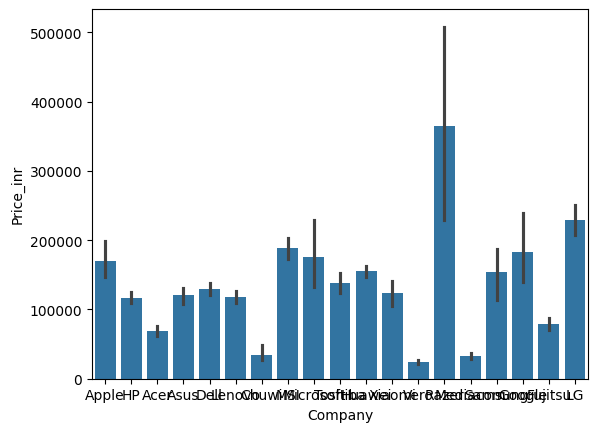

In [72]:
sns.barplot(x='Company', y='Price_inr', data=df)
plt.show()

In [73]:
import re

# Initialize storage columns
df['SSD'] = 0
df['HDD'] = 0
df['Hybrid'] = 0
df['Flash_Storage'] = 0

for idx, memory in enumerate(df['Memory']):

    # Split storage devices
    devices = memory.split(' + ')

    for device in devices:

        # Extract number
        size = int(re.findall(r'\d+', device)[0])

        # Convert TB to GB
        if 'TB' in device:
            size *= 1024

        # Assign storage type
        if 'SSD' in device:
            df.loc[idx, 'SSD'] += size

        elif 'HDD' in device:
            df.loc[idx, 'HDD'] += size

        elif 'Hybrid' in device:
            df.loc[idx, 'Hybrid'] += size

        elif 'Flash Storage' in device:
            df.loc[idx, 'Flash_Storage'] += size

In [74]:
df.head()

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price_inr,Touchscreen,IPS,PPI,Cpu_brand,SSD,HDD,Hybrid,Flash_Storage
0,Apple,Ultrabook,8.0,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,146026.21,0,1,226.983005,Intel Core i5,128,0,0,0
1,Apple,Ultrabook,8.0,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,97984.46,0,0,127.677940,Intel Core i5,0,0,0,128
2,HP,Notebook,8.0,256GB SSD,Intel HD Graphics 620,No OS,1.86,62675.00,0,0,141.211998,Intel Core i5,256,0,0,0
3,Apple,Ultrabook,16.0,512GB SSD,AMD Radeon Pro 455,macOS,1.83,276582.05,0,1,220.534624,Intel Core i7,512,0,0,0
4,Apple,Ultrabook,8.0,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,196592.40,0,1,226.983005,Intel Core i5,256,0,0,0


In [75]:
df['Gpu'].value_counts()

Gpu
Intel HD Graphics 620      281
Intel HD Graphics 520      185
Intel UHD Graphics 620      68
Nvidia GeForce GTX 1050     66
Nvidia GeForce GTX 1060     48
                          ... 
Nvidia Quadro M500M          1
AMD Radeon R7 M360           1
Nvidia Quadro M3000M         1
Nvidia GeForce 960M          1
ARM Mali T860 MP4            1
Name: count, Length: 110, dtype: int64

In [76]:
df.head(20)
#

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price_inr,Touchscreen,IPS,PPI,Cpu_brand,SSD,HDD,Hybrid,Flash_Storage
0,Apple,Ultrabook,8.0,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,146026.21,0,1,226.983005,Intel Core i5,128,0,0,0
1,Apple,Ultrabook,8.0,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,97984.46,0,0,127.677940,Intel Core i5,0,0,0,128
2,HP,Notebook,8.0,256GB SSD,Intel HD Graphics 620,No OS,1.86,62675.00,0,0,141.211998,Intel Core i5,256,0,0,0
3,Apple,Ultrabook,16.0,512GB SSD,AMD Radeon Pro 455,macOS,1.83,276582.05,0,1,220.534624,Intel Core i7,512,0,0,0
4,Apple,Ultrabook,8.0,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,196592.40,0,1,226.983005,Intel Core i5,256,0,0,0
5,Acer,Notebook,4.0,500GB HDD,AMD Radeon R5,Windows 10,2.10,43600.00,0,0,100.454670,AMD Processor,0,500,0,0
6,Apple,Ultrabook,16.0,256GB Flash Storage,Intel Iris Pro Graphics,Mac OS X,2.04,233256.73,0,1,220.534624,Intel Core i7,0,0,0,256
7,Apple,Ultrabook,8.0,256GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,126298.30,0,0,127.677940,Intel Core i5,0,0,0,256
8,Asus,Ultrabook,16.0,512GB SSD,Nvidia GeForce MX150,Windows 10,1.30,162955.00,0,0,157.350512,Intel Core i7,512,0,0,0
9,Acer,Ultrabook,8.0,256GB SSD,Intel UHD Graphics 620,Windows 10,1.60,83930.00,0,1,157.350512,Intel Core i5,256,0,0,0


In [77]:
df.drop(columns=['Memory'], inplace=True)

In [78]:
df.corr(numeric_only=True)['Price_inr'].sort_values(ascending=False)

Price_inr        1.000000
Ram              0.743007
SSD              0.670682
PPI              0.473487
IPS              0.252208
Weight           0.210370
Touchscreen      0.191226
Hybrid           0.008011
Flash_Storage   -0.040511
HDD             -0.094856
Name: Price_inr, dtype: float64

In [79]:
df.drop(columns=['Hybrid', 'Flash_Storage'], inplace=True)

In [80]:
df['Gpu_Brand']=df['Gpu'].apply(lambda x:x.split()[0])

In [81]:
df.drop(columns=['Gpu'], inplace=True)

In [82]:
df['Gpu_Brand'].value_counts()

Gpu_Brand
Intel     722
Nvidia    400
AMD       180
ARM         1
Name: count, dtype: int64

In [83]:
df=df[df['Gpu_Brand']!='ARM']

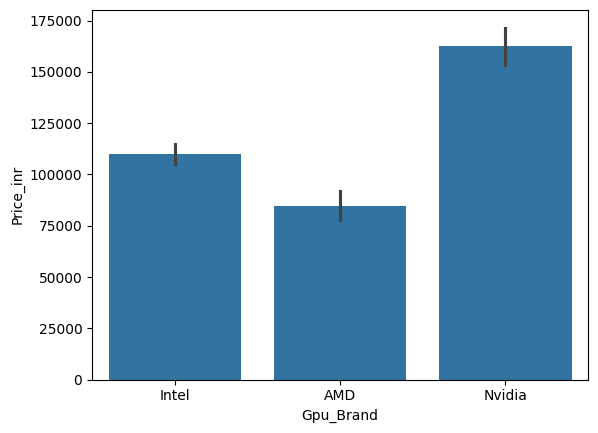

In [84]:
sns.barplot(x='Gpu_Brand', y='Price_inr', data=df)
plt.show()

In [85]:
df['OpSys'].value_counts()

OpSys
Windows 10      1072
No OS             66
Linux             62
Windows 7         45
Chrome OS         26
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64

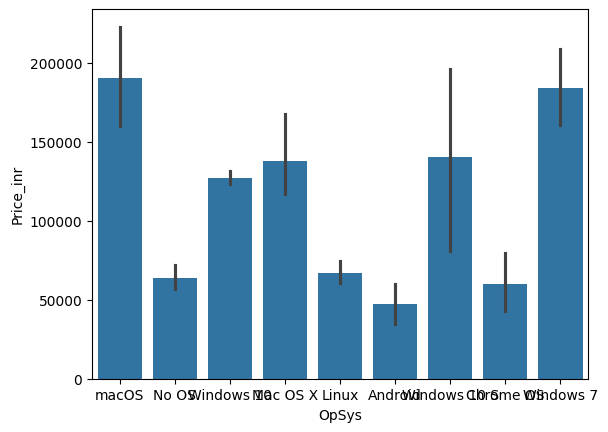

In [86]:
sns.barplot(x='OpSys', y='Price_inr', data=df)
plt.show()

In [87]:
def cat_os(inp):
    if inp == 'Windows 10' or inp == 'Windows 7' or inp == 'Windows 10 S':
        return 'Windows'

    elif inp == 'macOS' or inp == 'Mac OS X':
        return 'Mac'

    else:
        return 'Others/No OS/Linux'

In [88]:
df['os'] = df['OpSys'].apply(cat_os)

In [89]:
df.drop(columns=['OpSys'], inplace=True)

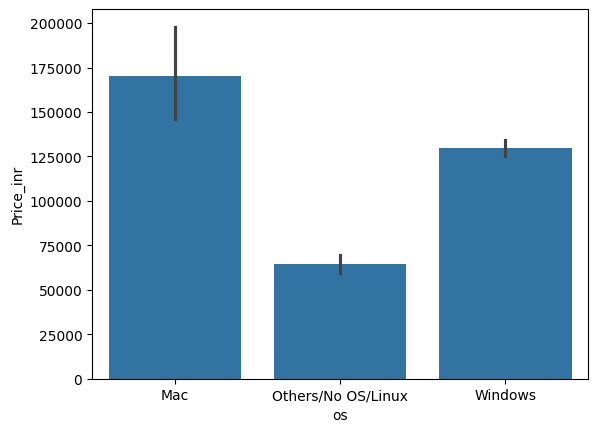

In [90]:
sns.barplot(x='os', y='Price_inr', data=df)
plt.show()

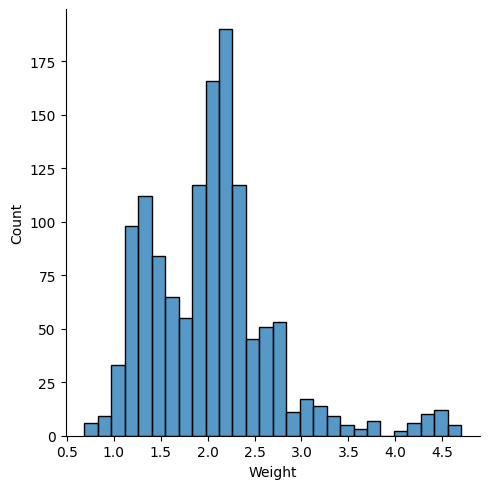

In [91]:
sns.displot(df['Weight'])
plt.show()

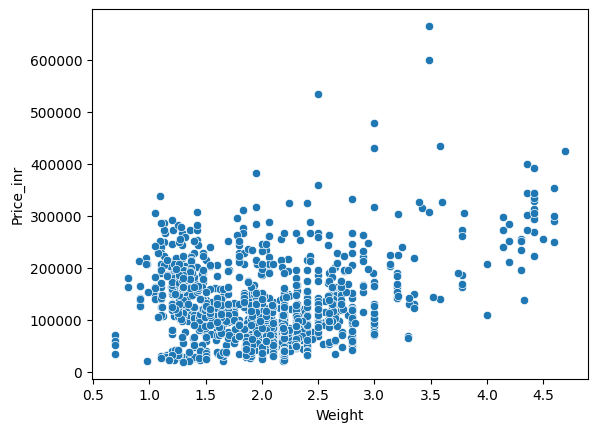

In [92]:
sns.scatterplot(x='Weight', y='Price_inr', data=df)
plt.show()

In [93]:
df.head()

,Company,TypeName,Ram,Weight,Price_inr,Touchscreen,IPS,PPI,Cpu_brand,SSD,HDD,Gpu_Brand,os
0,Apple,Ultrabook,8.0,1.37,146026.21,0,1,226.983005,Intel Core i5,128,0,Intel,Mac
1,Apple,Ultrabook,8.0,1.34,97984.46,0,0,127.677940,Intel Core i5,0,0,Intel,Mac
2,HP,Notebook,8.0,1.86,62675.00,0,0,141.211998,Intel Core i5,256,0,Intel,Others/No OS/Linux
3,Apple,Ultrabook,16.0,1.83,276582.05,0,1,220.534624,Intel Core i7,512,0,AMD,Mac
4,Apple,Ultrabook,8.0,1.37,196592.40,0,1,226.983005,Intel Core i5,256,0,Intel,Mac


In [94]:
cat_cols = ['Company', 'TypeName', 'Cpu_brand', 'Gpu_Brand', 'os']

In [95]:
X_cat = pd.get_dummies(df[cat_cols], drop_first=True)

In [96]:
from sklearn.feature_selection import f_regression

f_scores, p_values = f_regression(X_cat, df['Price_inr'])

In [97]:
anova_results = pd.DataFrame({
    'Feature': X_cat.columns,
    'F_score': f_scores,
    'P_value': p_values
})

anova_results = anova_results.sort_values(
    by='F_score',
    ascending=False
)

print(anova_results)

                            Feature     F_score        P_value
25          Cpu_brand_Intel Core i7  583.523810  8.522277e-107
20                TypeName_Notebook  564.334060  6.704487e-104
18                  TypeName_Gaming  213.598954   6.671607e-45
28                 Gpu_Brand_Nvidia  179.803878   1.700915e-38
26  Cpu_brand_Other Intel Processor  129.173062   1.323097e-28
23          Cpu_brand_Intel Core i3  114.583014   1.100594e-25
29            os_Others/No OS/Linux  111.723230   4.148145e-25
21               TypeName_Ultrabook   90.794486   7.500496e-21
22             TypeName_Workstation   86.459159   5.836206e-20
30                       os_Windows   77.308428   4.547198e-18
13                    Company_Razer   75.142334   1.281536e-17
27                  Gpu_Brand_Intel   46.014572   1.777604e-11
10                      Company_MSI   43.544057   6.019195e-11
24          Cpu_brand_Intel Core i5   15.405448   9.128062e-05
19                 TypeName_Netbook   12.518179   4.172

In [98]:
df = df[
    ['Company',
     'TypeName',
     'Ram',
     'Weight',
     'Price_inr',
     'Touchscreen',
     'IPS',
     'PPI',
     'Cpu_brand',
     'HDD',
     'SSD',
     'Gpu_Brand',
     'os']
]

In [99]:
X = df.drop(columns=['Price_inr'])
y = np.log1p(df['Price_inr'])

In [100]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=2
)

In [101]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
    ExtraTreesRegressor
)
from sklearn.svm import SVR
from xgboost import XGBRegressor

In [102]:
df.head(1)

,Company,TypeName,Ram,Weight,Price_inr,Touchscreen,IPS,PPI,Cpu_brand,HDD,SSD,Gpu_Brand,os
0,Apple,Ultrabook,8.0,1.37,146026.21,0,1,226.983005,Intel Core i5,0,128,Intel,Mac


In [103]:
df.head(1)

,Company,TypeName,Ram,Weight,Price_inr,Touchscreen,IPS,PPI,Cpu_brand,HDD,SSD,Gpu_Brand,os
0,Apple,Ultrabook,8.0,1.37,146026.21,0,1,226.983005,Intel Core i5,0,128,Intel,Mac


In [104]:
X.head()

,Company,TypeName,Ram,Weight,Touchscreen,IPS,PPI,Cpu_brand,HDD,SSD,Gpu_Brand,os
0,Apple,Ultrabook,8.0,1.37,0,1,226.983005,Intel Core i5,0,128,Intel,Mac
1,Apple,Ultrabook,8.0,1.34,0,0,127.677940,Intel Core i5,0,0,Intel,Mac
2,HP,Notebook,8.0,1.86,0,0,141.211998,Intel Core i5,0,256,Intel,Others/No OS/Linux
3,Apple,Ultrabook,16.0,1.83,0,1,220.534624,Intel Core i7,0,512,AMD,Mac
4,Apple,Ultrabook,8.0,1.37,0,1,226.983005,Intel Core i5,0,256,Intel,Mac


In [105]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from xgboost import XGBRegressor

In [106]:
models = {
    'LinearRegression':{
        'model':LinearRegression(),
        'params':{}
    },

    'ElasticNet':{
        'model':ElasticNet(),
        'params':{
            'model__alpha':[0.01,0.1,1],
            'model__l1_ratio':[0.2,0.5,0.8]
        }
    },

    'DecisionTree':{
        'model':DecisionTreeRegressor(random_state=42),
        'params':{
            'model__max_depth':[5,10,20,None],
            'model__min_samples_split':[2,5]
        }
    },

    'RandomForest':{
        'model':RandomForestRegressor(random_state=42),
        'params':{
            'model__n_estimators':[100,200],
            'model__max_depth':[10,20,None]
        }
    },

    'XGBoost':{
        'model':XGBRegressor(
            random_state=42,
            verbosity=0
        ),
        'params':{
            'model__n_estimators':[100,200],
            'model__max_depth':[4,6],
            'model__learning_rate':[0.05,0.1]
        }
    },

    'AdaBoost':{
        'model':AdaBoostRegressor(random_state=42),
        'params':{
            'model__n_estimators':[50,100],
            'model__learning_rate':[0.05,0.1]
        }
    },

    'GradientBoosting':{
        'model':GradientBoostingRegressor(random_state=42),
        'params':{
            'model__n_estimators':[100,200],
            'model__learning_rate':[0.05,0.1],
            'model__max_depth':[3,5]
        }
    },

    'SVR':{
        'model':SVR(),
        'params':{
            'model__C':[1,10,100],
            'model__epsilon':[0.1,0.2]
        }
    },

    'KNN':{
        'model':KNeighborsRegressor(),
        'params':{
            'model__n_neighbors':[3,5,7],
            'model__weights':['uniform','distance']
        }
    }
}

In [107]:
def get_best_model(model,params,X_train,y_train):

    cat_cols = X_train.select_dtypes(
        include='object'
    ).columns

    num_cols = X_train.select_dtypes(
        exclude='object'
    ).columns

    transformer = ColumnTransformer(
        transformers=[
            (
                'cat',
                OneHotEncoder(handle_unknown='ignore'),
                cat_cols
            ),
            (
                'num',
                StandardScaler(),
                num_cols
            )
        ]
    )

    pipe = Pipeline([
        ('preprocessor',transformer),
        ('model',model)
    ])

    grid = GridSearchCV(
        pipe,
        params,
        cv=5,
        scoring='r2',
        n_jobs=-1
    )

    grid.fit(X_train,y_train)

    return (
        grid.best_estimator_,
        grid.best_params_,
        grid.best_score_
    )

In [108]:
def train_all_models(
        models,
        X_train,
        y_train):

    best_model_dict = {}
    best_param_dict = {}

    for name,config in models.items():

        print(f'Training {name}')

        best_pipe,\
        best_params,\
        best_score = get_best_model(
            config['model'],
            config['params'],
            X_train,
            y_train
        )

        best_model_dict[name] = best_pipe
        best_param_dict[name] = best_params

        print(
            f'Best CV Score: {best_score:.4f}'
        )

    return (
        best_model_dict,
        best_param_dict
    )

In [109]:
best_model_dict,\
best_param_dict = train_all_models(
    models,
    X_train,
    y_train
)

Training LinearRegression


Best CV Score: 0.8176
Training ElasticNet
Best CV Score: 0.8043
Training DecisionTree
Best CV Score: 0.8079
Training RandomForest
Best CV Score: 0.8728
Training XGBoost
Best CV Score: 0.8809
Training AdaBoost
Best CV Score: 0.7816
Training GradientBoosting
Best CV Score: 0.8836
Training SVR
Best CV Score: 0.8675
Training KNN
Best CV Score: 0.8372


In [110]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

def evaluate_models(
        model_dict,
        X_test,
        y_test):

    y_true = np.expm1(y_test)

    for name,pipe in model_dict.items():

        pred_log = pipe.predict(X_test)

        pred = np.expm1(pred_log)

        r2 = r2_score(
            y_true,
            pred
        )

        mae = mean_absolute_error(
            y_true,
            pred
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_true,
                pred
            )
        )

        print("\n",name)
        print(
            f'R2   : {r2:.4f}'
        )
        print(
            f'MAE  : {mae:.2f}'
        )
        print(
            f'RMSE : {rmse:.2f}'
        )

In [111]:
evaluate_models(
    best_model_dict,
    X_test,
    y_test
)


 LinearRegression
R2   : 0.6476
MAE  : 25771.58
RMSE : 39756.83

 ElasticNet
R2   : 0.6897
MAE  : 24898.54
RMSE : 37308.23

 DecisionTree
R2   : 0.7391
MAE  : 22656.65
RMSE : 34210.26

 RandomForest
R2   : 0.8284
MAE  : 17999.59
RMSE : 27740.93

 XGBoost
R2   : 0.8012
MAE  : 18014.18
RMSE : 29862.26

 AdaBoost
R2   : 0.7083
MAE  : 25506.14
RMSE : 36175.16

 GradientBoosting
R2   : 0.7949
MAE  : 18202.15
RMSE : 30335.05

 SVR
R2   : 0.8099
MAE  : 18850.41
RMSE : 29201.28

 KNN
R2   : 0.7715
MAE  : 19843.62
RMSE : 32018.69


In [112]:
from sklearn.metrics import r2_score
import numpy as np

def select_best_pipe(model_dict, X_test, y_test):

    best_r2 = -np.inf
    best_pipe = None
    best_model_name = None

    y_true = np.expm1(y_test)

    for name, pipe in model_dict.items():

        # prediction in log scale
        y_pred_log = pipe.predict(X_test)

        # convert back to original price scale
        y_pred = np.expm1(y_pred_log)

        r2 = r2_score(y_true, y_pred)

        print(f"{name:<20} R2 Score: {r2:.4f}")

        if r2 > best_r2:
            best_r2 = r2
            best_pipe = pipe
            best_model_name = name

    return best_model_name, best_pipe, best_r2

In [113]:
best_model_name, best_pipe, best_r2 = select_best_pipe(
    best_model_dict,
    X_test,
    y_test
)

LinearRegression     R2 Score: 0.6476
ElasticNet           R2 Score: 0.6897
DecisionTree         R2 Score: 0.7391
RandomForest         R2 Score: 0.8284
XGBoost              R2 Score: 0.8012
AdaBoost             R2 Score: 0.7083
GradientBoosting     R2 Score: 0.7949
SVR                  R2 Score: 0.8099
KNN                  R2 Score: 0.7715


In [114]:
df.head()

,Company,TypeName,Ram,Weight,Price_inr,Touchscreen,IPS,PPI,Cpu_brand,HDD,SSD,Gpu_Brand,os
0,Apple,Ultrabook,8.0,1.37,146026.21,0,1,226.983005,Intel Core i5,0,128,Intel,Mac
1,Apple,Ultrabook,8.0,1.34,97984.46,0,0,127.677940,Intel Core i5,0,0,Intel,Mac
2,HP,Notebook,8.0,1.86,62675.00,0,0,141.211998,Intel Core i5,0,256,Intel,Others/No OS/Linux
3,Apple,Ultrabook,16.0,1.83,276582.05,0,1,220.534624,Intel Core i7,0,512,AMD,Mac
4,Apple,Ultrabook,8.0,1.37,196592.40,0,1,226.983005,Intel Core i5,0,256,Intel,Mac


In [115]:
import pickle

In [116]:
pickle.dump(df, open('../Model/df.pkl', 'wb'))
pickle.dump(best_pipe, open('../Model/pipe.pkl', 'wb'))

In [121]:
X_train.tail(1)

,Company,TypeName,Ram,Weight,Touchscreen,IPS,PPI,Cpu_brand,HDD,SSD,Gpu_Brand,os
1193,Apple,Ultrabook,8.0,0.92,0,1,226.415547,Other Intel Processor,0,0,Intel,Mac


In [122]:
np.exp(y.tail(1))

1302    40222.0
Name: Price_inr, dtype: float64